In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [32]:
df = pd.read_csv('/content/Customer Segmentation.zip')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [34]:
df.shape

(200, 5)

In [35]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [36]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [37]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [38]:
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

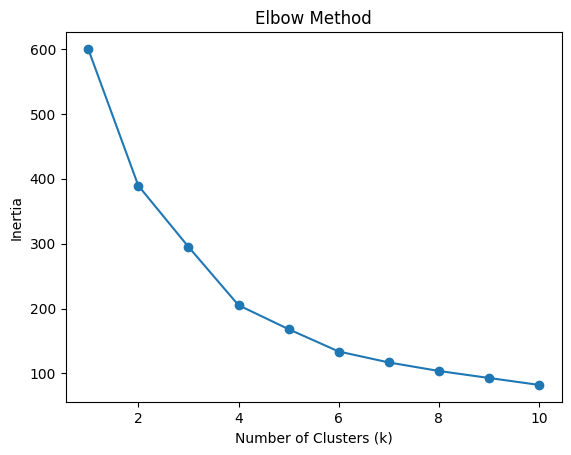

In [41]:
plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [42]:
k=4

In [43]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

In [44]:
df['KMeans_Cluster'].value_counts()

,count
KMeans_Cluster,
0,65
2,57
1,40
3,38


In [45]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.7, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels

In [46]:
df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,186
-1,14


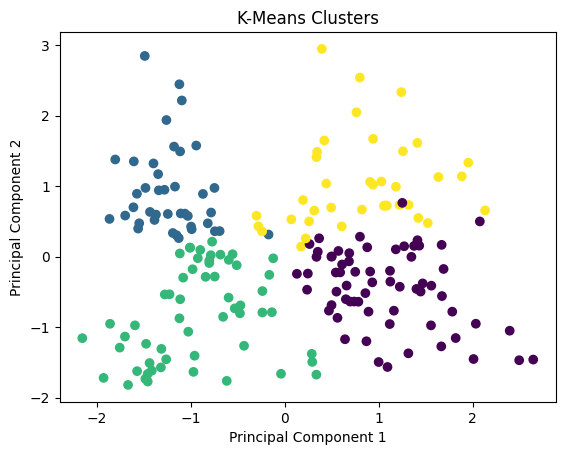

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [48]:
X_pca.shape

(200, 2)

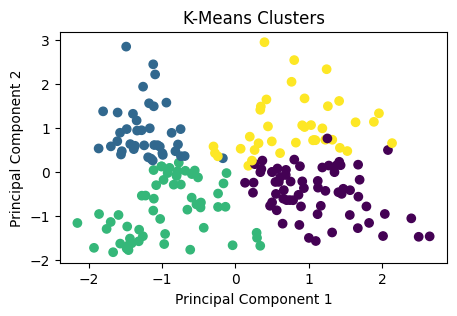

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters')

plt.show()

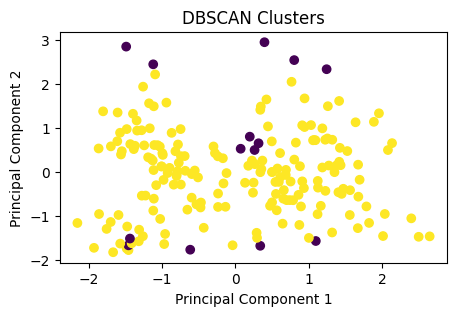

In [53]:
plt.figure(figsize=(5, 3))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    cmap='viridis'
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('DBSCAN Clusters')

plt.show()

In [55]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.4039582785148566


In [58]:
mask = dbscan_labels != -1
unique_labels = np.unique(dbscan_labels[mask])

if len(unique_labels) < 2:
    print("DBSCAN Silhouette Score cannot be calculated because only", len(unique_labels), "valid cluster was found (excluding noise).")
else:
    dbscan_score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
    print("DBSCAN Silhouette Score:", dbscan_score)

DBSCAN Silhouette Score cannot be calculated because only 1 valid cluster was found (excluding noise).


In [59]:
df['DBSCAN_Cluster'].value_counts()

,count
DBSCAN_Cluster,
0,186
-1,14


After scaling the features, the elbow method suggested 4 clusters for K-Means, and every customer was assigned to one of these four groups. The PCA plot shows four reasonably distinct customer segments based on similarities in age, annual income, and spending score. DBSCAN produced one main cluster containing 186 customers and identified 14 customers as noise (-1), meaning those points were in lower-density regions. Overall, K-Means created clearer fixed customer segments, while DBSCAN grouped most customers together and highlighted unusual customers as outliers.